<a href="https://colab.research.google.com/github/jasonyim2/book7/blob/main/Chapter07/Chapter_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 6: Holidays

## Adding default country holidays

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

df = pd.read_csv('/content/drive/MyDrive/Book7/data/divvy_daily.csv')
df = df[['date', 'rides']]
df['date'] = pd.to_datetime(df['date'])
df.columns = ['ds', 'y']

model = Prophet(seasonality_mode='multiplicative',
                yearly_seasonality=4)

In [3]:
model.add_country_holidays(country_name='US')

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp06j724u0/u6xep_yw.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp06j724u0/o_3ddbyy.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=52191', 'data', 'file=/tmp/tmp06j724u0/u6xep_yw.json', 'init=/tmp/tmp06j724u0/o_3ddbyy.json', 'output', 'file=/tmp/tmp06j724u0/prophet_modelwl4z9i53/prophet_model-20250811172819.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
17:28:19 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
17:28:20 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


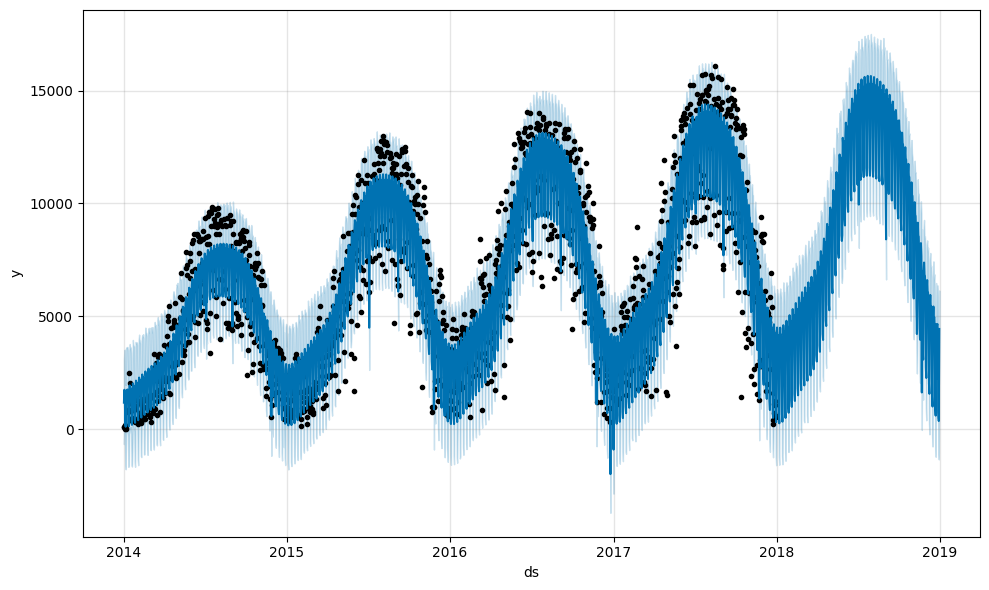

In [4]:
model.fit(df)
future = model.make_future_dataframe(periods=365)
forecast = model.predict(future)
fig = model.plot(forecast)
plt.show()

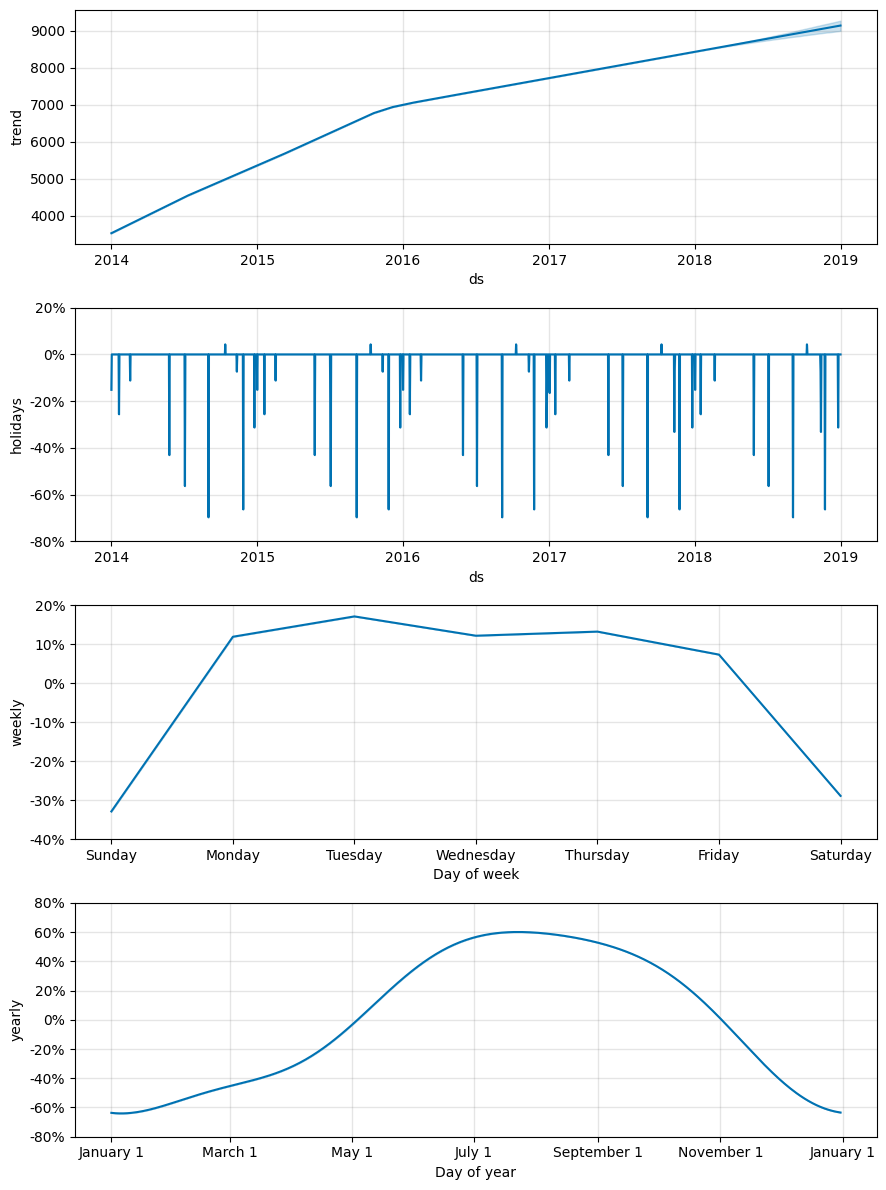

In [5]:
fig2 = model.plot_components(forecast)
plt.show()

In [6]:
model.train_holiday_names

,0
0,New Year's Day
1,Memorial Day
2,Independence Day
3,Labor Day
4,Veterans Day
5,Thanksgiving Day
6,Christmas Day
7,Christmas Day (observed)
8,Martin Luther King Jr. Day
9,Washington's Birthday


In [7]:
def first_non_zero(fcst, holiday):
    return fcst[fcst[holiday] != 0][holiday].values[0]

pd.DataFrame({'holiday': model.train_holiday_names,
              'effect': [first_non_zero(forecast, holiday)
                         for holiday in model.train_holiday_names]})

,holiday,effect
0,New Year's Day,-0.151649
1,Memorial Day,-0.430543
2,Independence Day,-0.563040
3,Labor Day,-0.696629
4,Veterans Day,-0.073596
5,Thanksgiving Day,-0.662743
6,Christmas Day,-0.312541
7,Christmas Day (observed),-0.205772
8,Martin Luther King Jr. Day,-0.255851
9,Washington's Birthday,-0.111737


## Adding default state/province holidays

In [8]:
# prohphet과 holidays 현재 버전 확인
import prophet, holidays
print("prophet:", prophet.__version__)
print("holidays:", holidays.__version__)


prophet: 1.1.7
holidays: 0.78


In [9]:
# 원서 코드지만 필요에 의해 다음 코드 블록에서 함수 재정의
from prophet.make_holidays import make_holidays_df

In [11]:
# 호환용 make_holidays_df 함수 재정의(역자 수정)
import holidays as _hol

def make_holidays_df(year_list, country, state=None):
    """
    Prophet의 make_holidays_df와 동일한 인터페이스.
    holidays 버전 차이를 흡수해 US-주(州) 휴일까지 포함한 데이터프레임을 생성.
    """
    # 최신 prophet 버전에서 주 반영을 위해 subdiv 인자를 사용하는 경우
    try:
        cal = _hol.country_holidays(country=country, years=year_list,
                                    subdiv=state)
    except TypeError:
        # 주 반영을 위해 state 인자를 사용하는 경우
        try:
            # 미국 전용 버전
            if country in ("US", "USA", "United States"):
                cal = _hol.US(years=year_list, state=state)
            else:
                cal = _hol.country_holidays(country=country,
                                            years=year_list, state=state)
        except TypeError:
            # 주 반영을 위해 prov 인자를 사용하는 경우
            try:
                if country in ("US", "USA", "United States"):
                    cal = _hol.UnitedStates(years=year_list, prov=state)
                else:
                    cal = _hol.country_holidays(country=country,
                                                years=year_list, prov=state)
            except TypeError:
                # 주(州) 인자 미지원이면 국가 공휴일만 반영
                cal = _hol.country_holidays(country=country, years=year_list)

    df = pd.DataFrame(
        [(pd.Timestamp(d), name) for d, name in sorted(cal.items())],
        columns=["ds", "holiday"]
    ).drop_duplicates(subset=["ds", "holiday"])

    return df


In [12]:
year_list = df['ds'].dt.year.unique().tolist()
# 마지막 연도를 확인하고 거기에 1을 더함
year_list.append(year_list[-1] + 1)

holidays = make_holidays_df(year_list=year_list,
                            country='US',
                            state='IL')

In [13]:
holidays.head()

,ds,holiday
0,2014-01-01,New Year's Day
1,2014-01-20,Martin Luther King Jr. Day
2,2014-02-12,Lincoln's Birthday
3,2014-02-17,Washington's Birthday
4,2014-03-03,Casimir Pulaski Day


## Creating multi-day holidays

In [14]:
model = Prophet(seasonality_mode='multiplicative',
                yearly_seasonality=4,
                holidays=holidays)
model.fit(df)
future = model.make_future_dataframe(periods=365)
forecast = model.predict(future)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp06j724u0/w4n3kax2.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp06j724u0/lcy_tw6s.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=84948', 'data', 'file=/tmp/tmp06j724u0/w4n3kax2.json', 'init=/tmp/tmp06j724u0/lcy_tw6s.json', 'output', 'file=/tmp/tmp06j724u0/prophet_modeldm3snnad/prophet_model-20250811175414.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
17:54:14 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
17:54:14 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [17]:
holidays = make_holidays_df(year_list=year_list, country='US')

In [18]:
black_friday = pd.DataFrame({'holiday': 'Black Friday',
                             'ds': pd.to_datetime(['2014-11-28',
                                                   '2015-11-27',
                                                   '2016-11-25',
                                                   '2017-11-24',
                                                   '2018-11-23'])})
christmas_eve = pd.DataFrame({'holiday': 'Christmas Eve',
                              'ds': pd.to_datetime(['2014-12-24',
                                                    '2015-12-24',
                                                    '2016-12-24',
                                                    '2017-12-24',
                                                    '2018-12-24'])})

In [19]:
holidays = pd.concat([holidays, black_friday, christmas_eve]
                    ).sort_values('ds').reset_index(drop=True)

In [20]:
model = Prophet(seasonality_mode='multiplicative',
                yearly_seasonality=4,
                holidays=holidays)
model.fit(df)
future = model.make_future_dataframe(periods=365)
forecast = model.predict(future)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmp06j724u0/hwezqwt2.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp06j724u0/3r38d8ng.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=4521', 'data', 'file=/tmp/tmp06j724u0/hwezqwt2.json', 'init=/tmp/tmp06j724u0/3r38d8ng.json', 'output', 'file=/tmp/tmp06j724u0/prophet_modelqiqpobdg/prophet_model-20250811180325.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
18:03:25 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
18:03:25 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [21]:
holidays = make_holidays_df(year_list=year_list, country='US')

taste_of_chicago = pd.DataFrame({'holiday': 'Taste of Chicago',
                                 'ds': pd.to_datetime(['2014-07-09',
                                                       '2015-07-08',
                                                       '2016-07-06',
                                                       '2017-07-05',
                                                       '2018-07-11']),
                                 'lower_window': 0,
                                 'upper_window': 4})
holidays = pd.concat([holidays, taste_of_chicago]
                    ).sort_values('ds').reset_index(drop=True)

In [22]:
holidays.head(10)

,ds,holiday,lower_window,upper_window
0,2014-01-01,New Year's Day,NaN,NaN
1,2014-01-20,Martin Luther King Jr. Day,NaN,NaN
2,2014-02-17,Washington's Birthday,NaN,NaN
3,2014-05-26,Memorial Day,NaN,NaN
4,2014-07-04,Independence Day,NaN,NaN
5,2014-07-09,Taste of Chicago,0.0,4.0
6,2014-09-01,Labor Day,NaN,NaN
7,2014-10-13,Columbus Day,NaN,NaN
8,2014-11-11,Veterans Day,NaN,NaN
9,2014-11-27,Thanksgiving Day,NaN,NaN


In [ ]:
model = Prophet(seasonality_mode='multiplicative',
                yearly_seasonality=4,
                holidays=holidays)
model.fit(df)
future = model.make_future_dataframe(periods=365)
forecast = model.predict(future)

16:23:28 - cmdstanpy - INFO - Chain [1] start processing
16:23:28 - cmdstanpy - INFO - Chain [1] done processing


In [ ]:
forecast[forecast['ds'].isin(['2018-07-11',
                              '2018-07-12',
                              '2018-07-13',
                              '2018-07-14',
                              '2018-07-15']
                            )][['ds',
                                'Taste of Chicago']]

,ds,Taste of Chicago
1649,2018-07-11,-0.036177
1650,2018-07-12,0.020332
1651,2018-07-13,0.069295
1652,2018-07-14,0.015054
1653,2018-07-15,0.021748


In [ ]:
from prophet.plot import plot_forecast_component

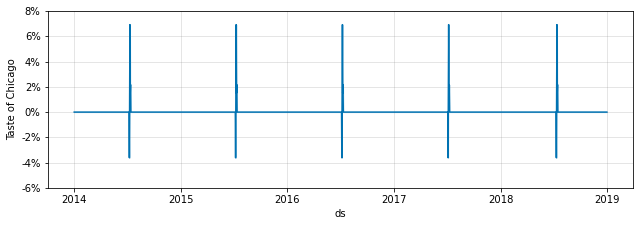

In [ ]:
fig3 = plot_forecast_component(model,
                               forecast,
                               'Taste of Chicago',
                               figsize=(10.5, 3.25))
plt.show()

## Regularizing holidays

### Global holiday regularization

16:23:30 - cmdstanpy - INFO - Chain [1] start processing
16:23:30 - cmdstanpy - INFO - Chain [1] done processing


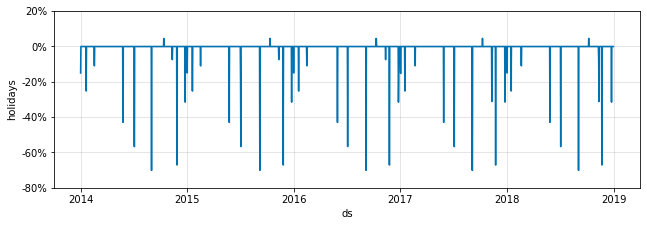

In [ ]:
model = Prophet(seasonality_mode='multiplicative',
                yearly_seasonality=4,
                holidays_prior_scale=10)
model.add_country_holidays(country_name='US')
model.fit(df)
future = model.make_future_dataframe(periods=365)
forecast = model.predict(future)
fig = plot_forecast_component(model,
                              forecast,
                              'holidays',
                              figsize=(10.5, 3.25))
plt.show()

16:23:32 - cmdstanpy - INFO - Chain [1] start processing
16:23:32 - cmdstanpy - INFO - Chain [1] done processing


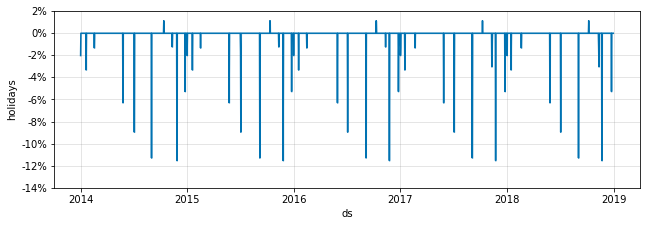

In [ ]:
model = Prophet(seasonality_mode='multiplicative',
                yearly_seasonality=4,
                holidays_prior_scale=0.05)
model.add_country_holidays(country_name='US')
model.fit(df)
future = model.make_future_dataframe(periods=365)
forecast = model.predict(future)
fig = plot_forecast_component(model,
                              forecast,
                              'holidays',
                              figsize=(10.5, 3.25))
plt.show()

### Individual holiday regularization

In [ ]:
holidays = make_holidays_df(year_list=year_list, country='US')

In [ ]:
black_friday = pd.DataFrame({'holiday': 'Black Friday',
                             'ds': pd.to_datetime(['2014-11-28',
                                                   '2015-11-27',
                                                   '2016-11-25',
                                                   '2017-11-24',
                                                   '2018-11-23']),
                             'prior_scale': 1})
christmas_eve = pd.DataFrame({'holiday': 'Christmas Eve',
                              'ds': pd.to_datetime(['2014-12-24',
                                                    '2015-12-24',
                                                    '2016-12-24',
                                                    '2017-12-24',
                                                    '2018-12-24']),
                              'prior_scale': 1})

taste_of_chicago = pd.DataFrame({'holiday': 'Taste of Chicago',
                                 'ds': pd.to_datetime(['2014-07-09',
                                                       '2015-07-08',
                                                       '2016-07-06',
                                                       '2017-07-05',
                                                       '2018-07-11']),
                                 'lower_window': 0,
                                 'upper_window': 4,
                                 'prior_scale': 0.1})

In [ ]:
holidays = pd.concat([holidays,
                      black_friday,
                      christmas_eve,
                      taste_of_chicago]
                    ).sort_values('ds').reset_index(drop=True)

In [ ]:
holidays.head(16)

,ds,holiday,prior_scale,lower_window,upper_window
0,2014-01-01,New Year's Day,NaN,NaN,NaN
1,2014-01-20,Martin Luther King Jr. Day,NaN,NaN,NaN
2,2014-02-17,Washington's Birthday,NaN,NaN,NaN
3,2014-05-26,Memorial Day,NaN,NaN,NaN
4,2014-07-04,Independence Day,NaN,NaN,NaN
5,2014-07-09,Taste of Chicago,0.1,0.0,4.0
6,2014-09-01,Labor Day,NaN,NaN,NaN
7,2014-10-13,Columbus Day,NaN,NaN,NaN
8,2014-11-11,Veterans Day,NaN,NaN,NaN
9,2014-11-27,Thanksgiving,NaN,NaN,NaN


In [ ]:
model = Prophet(seasonality_mode='multiplicative',
                yearly_seasonality=4,
                holidays=holidays,
                holidays_prior_scale=10)
model.fit(df)
future = model.make_future_dataframe(periods=365)
forecast = model.predict(future)

16:23:35 - cmdstanpy - INFO - Chain [1] start processing
16:23:35 - cmdstanpy - INFO - Chain [1] done processing
